In [36]:
import pickle
import numpy as np
import nltk
from utils import extract_features

nltk.download('twitter_samples')
nltk.download('stopwords')

################################################################################
#@title Q1.1 Sigmoid Inference
################################################################################

def sigmoid( x ):
  """
  This function implements the logistic regression algorithm.

  Args:
    x: A numpy array of shape (d,) or (N, d) representing
      the input data.

  Returns:
    y: A numpy array of shape (l,) or (N, l) representing
      the output data.
  """
  y = 1 / (1 + np.exp(-x))
  return y

def sigmoid_test():
  x = np.array([1, 2, 3])
  y = sigmoid(x)
  assert np.allclose(y, np.array([0.73105858, 0.88079708, 0.95257413]))
  print('sigmoid: \033[1;32mtests OK.\033[0m')

def inference_layer(X, W, b):
  """
  Implements the forward propagation for the logistic regression model.

  Args:
    X: The input data, of shape (number of features, number of examples).
    W: Weights, a numpy array of shape (number of features, 1).
    b: Bias, a scalar.

  Returns:
    y: The output of shape l or l x N
  """
  y = sigmoid(W @ X + b[:, None])
  return y

def inference_layer_test():
  X = np.array([[1, 2, 3, 4, 5, 6], [4, 5, 6, 7, 8, 9]])
  W = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]])
  b = np.array([1, 2, 3])
  y = inference_layer(X, W, b)
  assert np.allclose(y, np.array(
      [[0.86989153, 0.90024951, 0.92414182, 0.94267582, 0.95689275, 0.96770454], \
       [0.98015969, 0.9900482,  0.9950332,  0.99752738, 0.9987706,  0.99938912], \
       [0.99726804, 0.99908895, 0.99969655, 0.99989897, 0.99996637, 0.9999888 ]]))
  print('inference_layer: \033[1;32mtests OK.\033[0m')

def inference_2layers(X, W1, W2, b1, b2):
  """
  Implements the forward propagation of a two layer neural network
  model.

  - Let d be the number of features (dimensionality) of the input.
  - Let N be the number of data samples in your batch
  - Let H be the number of hidden units

  Args:
  X: The input data, with shape either d or d x N
  W1: Weights for the first weight matrix: shape = H x d
  w2: Weights for the second matrix: shape = 1 x H
  b1: Bias value for first layer
  b2: Bias value for second layer

  Returns:
  y: Singular output data (1, 0), with shape either 1 or N.
  """
  h = sigmoid(W1 @ X + b1[:, None])
  yhat = sigmoid(W2 @ h + b2[:, None])
  return yhat

def inference_2layers_test():
  X = np.array([[1, 2, 3, 4], [4, 5, 6, 7]])
  W1 = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]])
  W2 = np.array([[0.7, 0.8, 0.9]])
  b1 = np.array([1, 2, 3])
  b2 = np.array([4])
  yhat = inference_2layers(X, W1, W2, b1, b2)
  assert np.allclose(yhat, np.array([[0.99814977, 0.99820579, 0.99824346, 0.99826983]]))
  print('inference_2layers: \033[1;32mtests OK.\033[0m')

def bce_forward(yhat, y):
  """
  This function calculates the gradient of the logistic regression cost
  function with respect to the weights and biases.

  Args:
    yhat: A numpy array of shape (N,) representing the predicted outputs
    y: A numpy array of shape (N,) representing the target labels.

  Returns:
    loss_value
  """
  loss_value = -np.mean(y * np.log(yhat) + (1 - y) * np.log(1 - yhat))
  return loss_value

def bce_forward_test():
  yhat = np.array([0.5, 0.5, 0.5])
  y = np.array([0, 1, 0])
  loss_value = bce_forward(yhat, y)
  assert np.allclose(loss_value, 0.6931471805599453)
  print('bce_forward: \033[1;32mtests OK.\033[0m')

def gradients(X, y, W1, W2, b1, b2):
  '''
  Calculate the gradients of the cost functions with respect to W1, W2, b1, and b2.

  Args:
    W1: Weight np.array of shape (h, d), first layer
    b1: Bias np.array of shape (h,), first layer
    W1: Weight np.array of shape (1, h), second layer
    b1: Bias value, second layer
    X: Input data of shape (d, N) representing the input data.
    y: Target / output labels of shape (N,)

  Returns:
    dL/dW1: Derivative of cost fxn w/r/t W1
    dL/db1: Derivative of cost fxn w/r/t b1
    dL/dW2: Derivative of cost fxn w/r/t W2
    dL/db2: Derivative of cost fxn w/r/t b2
    L: Loss value
  '''
  h = sigmoid(W1 @ X+ b1[:, None])
  yhat = sigmoid(W2 @ h + b2[:, None])
  L = bce_forward(yhat, y)
    
  dL_dW2 = (yhat - y) @ h.T
  dL_db2 = np.sum(yhat - y)
    
  dz1 = W2.T @ (yhat - y) * h * (1 - h)
  dL_dW1 = dz1 @ X.T
  dL_db1 = np.sum(dz1, axis = 1)
    
  return dL_dW1, dL_db1, dL_dW2, dL_db2, L

def gradients_test():

  X = np.array([[1, 2, 3], [4, 5, 6]])
  y = np.array([0, 1, 0])
  W1 = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]])
  b1 = np.array([0.1, 0.2, 0.3])
  W2 = np.array([[0.7, 0.8, 0.9]])
  b2 = np.array([0.3])
  dL_dW1, dL_db1, dL_dW2, dL_db2, L = gradients(X, y, W1, W2, b1, b2)

  assert dL_dW1.shape == (3, 2), "dL_dW1 should have shape (3, 2). It is currently %s" % str(dL_dW1.shape)
  assert dL_db1.shape == (3,), "dL_db1 should have shape (3,). It is currently %s" % str(dL_db1.shape)
  assert dL_db1.shape == (3,), "dL_db1 should have shape (3,). It is currently %s" % str(dL_db1.shape)
  assert dL_dW2.shape == (1, 3), "dL_dW2 should have shape (1, 3). It is currently %s" % str(dL_dW2.shape)
  assert dL_db2.shape == () or dL_db2.shape == (1,), "dL_db2 should have shape (). It is currently %s" % str(dL_db2.shape)

  expected_dL_dW1 = np.array([[0.38040779, 1.00394945],
   [0.12798198, 0.39510952], [0.04042118, 0.14198144]])
  assert np.allclose(dL_dW1, expected_dL_dW1), \
    "dL_dW1 is \n" + str(dL_dW1) + " but should be \n" + str(expected_dL_dW1)

  expected_dL_db1 = np.array([0.20784722, 0.08904251, 0.03385342])
  assert np.allclose(dL_db1, expected_dL_db1), \
    "dL_db1 is \n" + str(dL_db1) + " but should be \n" + str(expected_dL_db1)

  expected_dL_dW2 = np.array([[1.38163852, 1.64474415, 1.72847074]])
  assert np.allclose(dL_dW2, expected_dL_dW2), \
    "dL_dW2 is \n" + str(dL_dW2) + " but should be \n" + str(expected_dL_dW2)

  expected_dL_db2 = 1.767495823193705
  expected_dL_db2_array = np.array([1.767495823193705])
  assert np.allclose(dL_db2, expected_dL_db2) or np.allclose(dL_db2, expected_dL_db2_array), \
    "dL_db2 is \n" + str(dL_db2) + " but should be \n" + str(expected_dL_db2)

  expected_L = 1.7287272636229514
  assert np.allclose(L, expected_L), \
    "L is \n" + str(L) + " but should be \n" + str(expected_L)

  print('gradients: \033[1;32mtests OK.\033[0m')

def update_params(batchx, batchy, W1, b1, W2, b2, lr = 0.01):
    '''
    Updates your parameters
        batchx: Mini-batch of features
        batchy: Corresponding mini-batch of labels
        W1: Starting value of W1
        b1: Starting value of b1
        W2: Starting value of W2
        b2: Starting value of b2
        lr: Learning parameter, default to 0.01

    Returns
        W1: New value of W1
        b1: New value of b1
        W2: New value of W2
        b2: New value of b2
        L: Loss value
    '''
    dL_dW1, dL_db1, dL_dW2, dL_db2, L = gradients(batchx, batchy, W1, W2, b1, b2)
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    return W1, b1, W2, b2, L

def update_params_test():
  X = np.array([[1, 2, 3], [4, 5, 6]])
  y = np.array([0, 1, 0])
  W1 = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]])
  b1 = np.array([0.1, 0.2, 0.3])
  W2 = np.array([[0.7, 0.8, 0.9]])
  b2 = np.array([0.3])
  W1, b1, W2, b2, L = update_params(X, y, W1, b1, W2, b2)

  assert W1.shape == (3, 2), "W1 should have shape (3, 2). It is currently %s" % str(W1.shape)
  assert b1.shape == (3,), "b1 should have shape (3,). It is currently %s" % str(b1.shape)
  assert W2.shape == (1, 3), "W2 should have shape (1, 3). It is currently %s" % str(W2.shape)
  assert b2.shape == () or b2.shape == (1,), "b2 should have shape (). It is currently %s" % str(b2.shape)

  expected_W1 = np.array([[0.09619592, 0.18996051],
   [0.29872018, 0.3960489 ],[0.49959579, 0.59858019]])
  assert np.allclose(W1, expected_W1), \
    "new W1 is \n" + str(W1) + " but should be \n" + str(expected_W1)

  expected_b1 = np.array([0.09792153, 0.19910957, 0.29966147])
  assert np.allclose(b1, expected_b1), \
    "new b1 is \n" + str(b1) + " but should be \n" + str(expected_b1)

  expected_W2 = np.array([[0.68618361, 0.78355256, 0.88271529]])
  assert np.allclose(W2, expected_W2), \
    "W2 is \n" + str(W2) + " but should be \n" + str(expected_W2)

  expected_b2 = 0.28232504
  expected_b2_array = np.array([0.28232504])
  assert np.allclose(b2, expected_b2) or np.allclose(b2, expected_b2_array), \
    "b2 is \n" + str(b2) + " but should be \n" + str(expected_b2)

  expected_L = 1.7287272636229514
  expected_L_array = np.array([1.7287272636229514])
  assert np.allclose(L, expected_L) or np.allclose(L, expected_L_array), \
    "L is \n" + str(L) + " but should be \n" + str(expected_L)

  print('update_params: \033[1;32mtests OK.\033[0m')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/dyh/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/dyh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
# x = np.array([1, 2, 3])
# sigmoid( x )
# sigmoid_test()
update_params_test()

update_params: tests OK.


In [38]:
import assignment2

assignment2.sigmoid_test()

assignment2.inference_layer_test()

assignment2.inference_2layers_test()

assignment2.bce_forward_test()

assignment2.gradients_test()

assignment2.update_params_test()

assignment2.train_nn_test()

sigmoid: tests OK.
inference_layer: tests OK.
inference_2layers: tests OK.
bce_forward: tests OK.
gradients: tests OK.
update_params: tests OK.
train_nn: tests OK. Please thoroughly test convergence


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/dyh/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/dyh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [47]:
%run assignment2.py

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/dyh/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/dyh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


sigmoid: tests OK.
inference_layer: tests OK.
inference_2layers: tests OK.
bce_forward: tests OK.
gradients: tests OK.
update_params: tests OK.
train_nn: tests OK. Please thoroughly test convergence
First 10 losses:
[np.float64(0.6907307267494407), np.float64(0.6875153954879225), np.float64(0.6883159168395694), np.float64(0.6848994096553018), np.float64(0.6856567084013505), np.float64(0.6865859847085304), np.float64(0.6875727964582771), np.float64(0.687869728211133), np.float64(0.6863566767998198), np.float64(0.6853305233894114)]
Last 10 losses:
[np.float64(0.03553960583576932), np.float64(0.036922862804151246), np.float64(0.04261392232627174), np.float64(0.052518891495914766), np.float64(0.03464005610709488), np.float64(0.07130768303117344), np.float64(0.03463930984278463), np.float64(0.04327410272763155), np.float64(0.08982757208818776), np.float64(0.03539851711574436)]


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/dyh/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/dyh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


sigmoid: tests OK.
inference_layer: tests OK.
inference_2layers: tests OK.
bce_forward: tests OK.
gradients: tests OK.
update_params: tests OK.
train_nn: tests OK. Please thoroughly test convergence
First 10 losses:
[np.float64(0.7007072396333689), np.float64(0.6997973619349023), np.float64(0.7000445257295835), np.float64(0.6982844292492745), np.float64(0.6997004699615321), np.float64(0.699044630674402), np.float64(0.6993331847373293), np.float64(0.6989027805639297), np.float64(0.6988472114886539), np.float64(0.6987288483369234)]
Last 10 losses:
[np.float64(0.026671029606084945), np.float64(0.03710137759526886), np.float64(0.029982825254850604), np.float64(0.026475821127212994), np.float64(0.026131493092190965), np.float64(0.026161838787575966), np.float64(0.09169297053628911), np.float64(0.032333214205256554), np.float64(0.03296183925804867), np.float64(0.026349414943596328)]


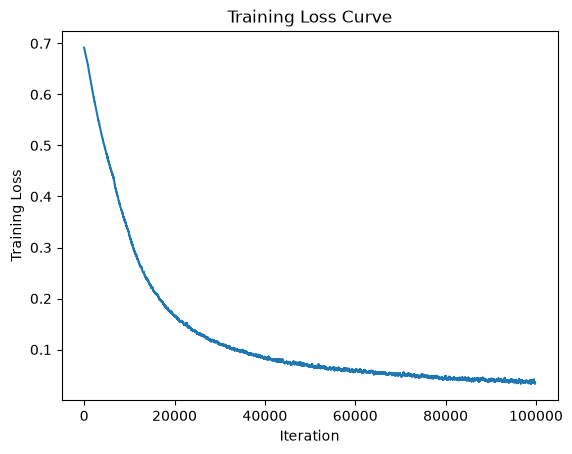

Test loss: 0.035363211770340984
Test accuracy: 0.9955
Example 1
Tweet: Bro:U wan cut hair anot,ur hair long Liao bo
Me:since ord liao,take it easy lor treat as save $ leave it longer :)
Bro:LOL Sibei xialan
True label: Positive
Predicted probability: 0.9753793329041536
Predicted label: Positive
--------------------------------
Example 2
Tweet: @heyclaireee is back! thnx God!!! i'm so happy :)
True label: Positive
Predicted probability: 0.9753793329041536
Predicted label: Positive
--------------------------------
Example 3
Tweet: @BBCRadio3 thought it was my ears which were malfunctioning, thank goodness you cleared that one up with an apology :-)
True label: Positive
Predicted probability: 0.9753792700049324
Predicted label: Positive
--------------------------------
Example 4
Tweet: @HumayAG 'Stuck in the centre right with you. Clowns to the right, jokers to the left...' :) @orgasticpotency @ahmedshaheed @AhmedSaeedGahaa
True label: Positive
Predicted probability: 0.9753793329041536
Pr

In [66]:
%run assignment2.py

In [63]:
# Source - https://stackoverflow.com/q/35067957
# Posted by Kenenbek Arzymatov, modified by community. See post 'Timeline' for change history
# Retrieved 2026-09-25, License - CC BY-SA 4.0

with open('twitter_data.pkl', 'rb') as f:
    x = pickle.load(f)
x


{'train_x': ['#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)',
  '@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!',
  '@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!',
  '@97sides CONGRATS :)',
  'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days',
  '@BhaktisBanter @PallaviRuhail This one is irresistible :)\n#FlipkartFashionFriday http://t.co/EbZ0L2VENM',
  "We don't like to keep our lovely customers waiting for long! We hope you enjoy! Happy Friday! - LWWF :) https://t.co/smyYriipxI",
  '@Impatientraider On second thought, there’s just not enough time for a DD :) But new shorts entering system. Sheep must be buying.',
  'Jgh , but we have to go to Bayan :D bye',
  'As an act of mischievousness, am calling the ETL layer of our 